Example notebook to read CMIP output and plot time series of different variables for specified locations.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis

### Set time coder to read cftime without errors

In [2]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

### Specify locations and variables to diagnose

In [ ]:
#These are four handpicked locations

#Arrays of indices per location
ii = [190,245,380,665] # Indices on x-dimension
jj = [334,460,265,260] # Indices on y-dimension
kk = [10, 10, 10, 10]  # Indices on z-dimension

#Names of the locations 
titles = ['Thwaites','FRIS','Ross','Totten']

#Array of variable names
varr = ['thetao','tf','so']

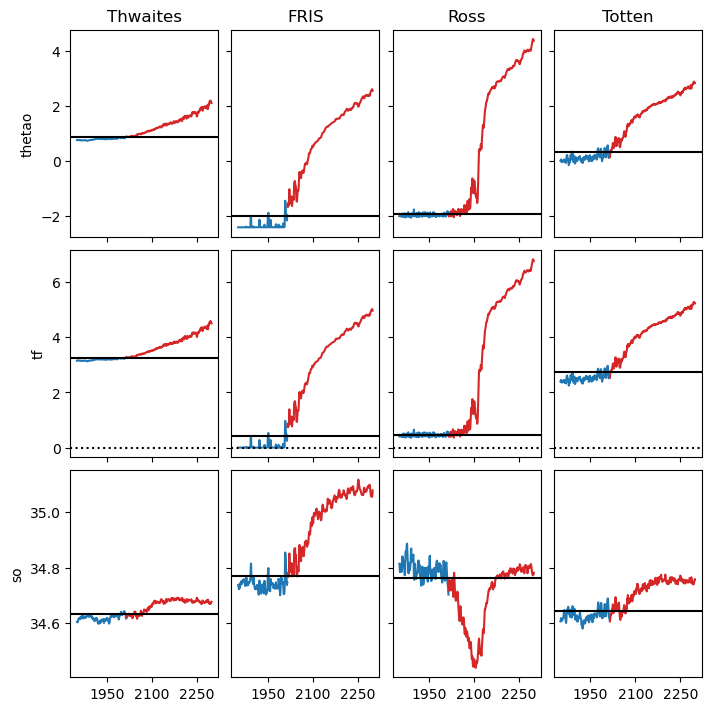

In [ ]:
# Prepare figure and subplots
fig,ax = plt.subplots(3,4,figsize=(7,7),sharey='row',sharex=True,constrained_layout=True)

# Loop over requested variables
for v,var in enumerate(varr):
    # Open the historical files into 1 dataset
    ds0 = xr.open_mfdataset(f'~/data/ismip7_distr/historical/zhou_annual_06_nov/Oyr/thetao_so_tf/{var}*.nc',decode_times=time_coder)
    
    # Open the SSP files into 1 dataset
    ds = xr.open_mfdataset(f'~/data/ismip7_distr/ssp585/zhou_annual_06_nov/Oyr/thetao_so_tf/{var}*.nc',decode_times=time_coder)

    # Open the climatology file
    dsc = xr.open_dataset(f'~/data/ismip7_distr/zhou_annual_06_nov/OI_Climatology_ismip8km_60m_{var}_extrap.nc')

    # Loop over requested locations
    for n,(i,j,k,title) in enumerate(zip(ii,jj,kk,titles)):

        # Plot the historical period
        ax[v,n].plot(ds0.time,ds0[var][:,k,j,i],c='tab:blue')
        
        # Plot the projection period
        ax[v,n].plot(ds.time,ds[var][:,k,j,i],c='tab:red')

        # Plot the climatology
        ax[v,n].axhline(dsc[var][k,j,i],0,1,c='k')

        # Add some attributes to the panels
        if v == 1:
            ax[v,n].axhline(0,0,1,c='k',ls=':')
        if v==0:
            ax[v,n].set_title(title)
        if n==0:
            ax[v,n].set_ylabel(var)

        # Comment out to zoom into a specific time period
        #ax[v,n].set_xlim([ds.time[190].values,ds.time[230].values])
